In [1]:
import math
import torch
import torch.nn as nn
import numpy as np
import scipy
import matplotlib.pyplot as plt
from torchsummary import summary
import cv2
%matplotlib inline

import deepwave # pacote de geofísica que faz a propagação do campo de ondas
from deepwave import scalar
device = torch.device('cuda:0') # defino o device aqui porque o deepwave já vai usá-lo antes de qualquer definição de rede

In [2]:
#importa o modelo de velocidades que vai ser usado para gerar o dado "adquirido" e que é alvo da inversão
model=np.load('modelo_BP.npy')

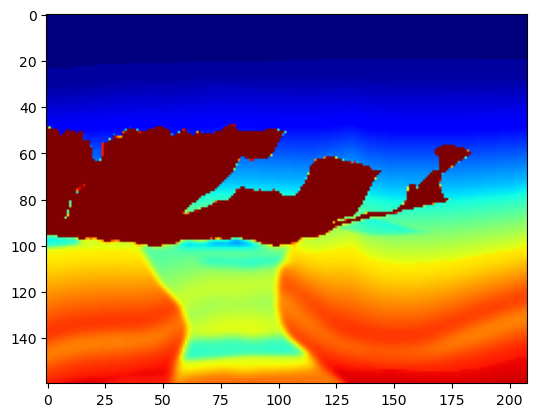

In [3]:
model_npy=cv2.resize(model,(208,160)).T 
plt.imshow(model_npy.T, cmap='jet')

In [4]:
#configurações da aquisição geofísica a serem usadas no deepwave
dx = 10.0 # 10m de grid na vertical e horizontal
dt = 0.002 # 2ms de intervalo de registro dos tiros
nz = 160
ny = 208
nt = 960
peak_freq = 8
peak_source_time = 1/peak_freq
peak_time = 1.0 / peak_freq

# desenho da aquisição, 1 receptor em cada cela do modelo, receptores com posições fixas, o que se move é a fonte
num_dims = 2
num_shots = 20
num_sources_per_shot = 1
num_receivers_per_shot = 208
source_spacing = 10 #250*10m=2500m
receiver_spacing = 1#1*10m
first_source=4
first_receiver=0
source_depth=1
receiver_depth=1

model =torch.ones(ny, nz) * model_npy 
model_prop=model.to(device)

C:\Users\Eder Dias\AppData\Local\Temp\ipykernel_17732\888287264.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  model =torch.ones(ny, nz) * model_npy


In [5]:
# source_locations
source_locations = torch.zeros(num_shots,num_sources_per_shot,2,
                               dtype=torch.long, device=device)
source_locations[..., 1] = source_depth
source_locations[:, 0, 0] = torch.arange(num_shots)*source_spacing+ first_source

# receiver_locations
receiver_locations = torch.zeros(num_shots,num_receivers_per_shot, 2,
                                 dtype=torch.long, device=device)
receiver_locations[..., 1] = receiver_depth
receiver_locations[:, :, 0] = (
    (torch.arange(num_receivers_per_shot)*receiver_spacing + first_receiver)
    .repeat(num_shots, 1)
)

# source_amplitudes
source_amplitudes = (
    deepwave.wavelets.ricker(peak_freq, nt, dt,peak_time)
    .repeat(num_shots,num_sources_per_shot, 1)
    .to(device)
)

In [6]:
# simula a aquisição
out = scalar(model_prop,dx,dt,source_amplitudes=source_amplitudes,
             source_locations=source_locations,
             receiver_locations=receiver_locations,
             accuracy=8,
             pml_freq=peak_freq,pml_width=[50,50,50,50])
receiver_amplitudes=out[-1]

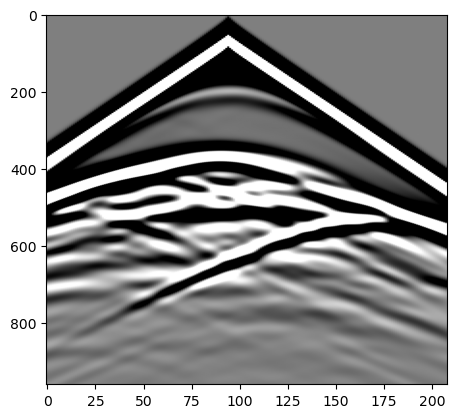

In [7]:
vmin, vmax = torch.quantile(receiver_amplitudes[0],
                            torch.tensor([0.05, 0.95]).to(device))
plt.imshow(receiver_amplitudes[9,:,:].cpu().T*-1, cmap='gray',
             vmin=-vmax/5,vmax=vmax/5,aspect=0.2)

In [8]:
# Construcao da rede neural
class EncoderBlock(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.encoder_block = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,2),stride=(2,2),padding=0)
        )

    def forward(self, x):
        return self.encoder_block(x)

class DecoderBlock(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.decoder_block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
        )

    def forward(self, x):
        return self.decoder_block(x)


class FinalConv(nn.Module):
    """(reduce final feature maps to one channel)"""

    def __init__(self, in_channels, out_channels=1):
        super().__init__()
        self.final_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same", bias=False),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.final_conv(x)


class TestEncoderDecoder(nn.Module):
    def __init__(self, n_channels,filters):
        super(TestEncoderDecoder, self).__init__()
        self.n_channels = n_channels
        self.filters = filters

        self.encoder_1 = EncoderBlock(n_channels, filters)
        self.encoder_2 = EncoderBlock(filters, filters*2)
        self.encoder_3 = EncoderBlock(filters*2, filters*4)
        self.encoder_4 = EncoderBlock(filters*4, filters*8)

        self.decoder_1 = DecoderBlock(filters*8, filters*8)
        self.decoder_2 = DecoderBlock(filters*8, filters*4)
        self.decoder_3 = DecoderBlock(filters*4, filters*2)
        self.decoder_4 = DecoderBlock(filters*2, filters*1)

        self.outc = FinalConv(filters)

    def forward(self, x):
        x1 = self.encoder_1(x)
        x2 = self.encoder_2(x1)
        x3 = self.encoder_3(x2)
        x4 = self.encoder_4(x3)

        x6 = self.decoder_1(x4)

        x7 = self.decoder_2(x6)
        x8 = self.decoder_3(x7)
        x9 = self.decoder_4(x8)

        logits = self.outc(x9)

        return logits

In [9]:
n_filters=36
net=TestEncoderDecoder(num_shots,filters=n_filters).to(device)
summary(net,(20,208,160))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 36, 208, 160]           6,480
       BatchNorm2d-2         [-1, 36, 208, 160]              72
         LeakyReLU-3         [-1, 36, 208, 160]               0
            Conv2d-4         [-1, 36, 208, 160]          11,664
       BatchNorm2d-5         [-1, 36, 208, 160]              72
         LeakyReLU-6         [-1, 36, 208, 160]               0
         MaxPool2d-7          [-1, 36, 104, 80]               0
      EncoderBlock-8          [-1, 36, 104, 80]               0
            Conv2d-9          [-1, 72, 104, 80]          23,328
      BatchNorm2d-10          [-1, 72, 104, 80]             144
        LeakyReLU-11          [-1, 72, 104, 80]               0
           Conv2d-12          [-1, 72, 104, 80]          46,656
      BatchNorm2d-13          [-1, 72, 104, 80]             144
        LeakyReLU-14          [-1, 72, 

In [15]:
#DEFININDO O DADO DE ENTRADA DA REDE DENTRO DO MODELO DE USO DE TIROS COMO ENTRADA
# o que entra na rede é reamostrado para ficar com as mesmas dimensões da saída
x=torch.Tensor(torch.reshape(receiver_amplitudes,(1,num_shots,num_receivers_per_shot,nt))[:,:,:,0:1600:6]).to(device)
print(x.shape)
# NOTA: OS SISMOGRAMAS DE REFERENCIA PARA CALCULO DA LOSS  NÃO SAO OS MESMOS. ELES NÃO FORAM REAMOSTRADOS, apenas vão para o device e ganham uma dimensão extra
true_seism=torch.reshape(receiver_amplitudes,(1,num_shots,num_receivers_per_shot,nt)).to(device)

torch.Size([1, 20, 208, 160])


In [16]:
batch_size=5 # batch de tiros para cálculo do FWI- se estourar memória, reduzir esse valor
num_batch=int(num_shots/batch_size)

Epoca: 1 Erro dado: 0.3840524032711983 Erro modelo: 1689302.875
Epoca: 2 Erro dado: 0.291531577706337 Erro modelo: 1654660.375
Epoca: 3 Erro dado: 0.2682645618915558 Erro modelo: 1358683.625
Epoca: 4 Erro dado: 0.24973226338624954 Erro modelo: 913616.625
Epoca: 5 Erro dado: 0.2350684441626072 Erro modelo: 700771.8125
Epoca: 6 Erro dado: 0.22306236624717712 Erro modelo: 626378.4375
Epoca: 7 Erro dado: 0.21139179170131683 Erro modelo: 528775.1875
Epoca: 8 Erro dado: 0.19989798218011856 Erro modelo: 491944.5625
Epoca: 9 Erro dado: 0.18896400928497314 Erro modelo: 459764.40625
Epoca: 10 Erro dado: 0.17753712832927704 Erro modelo: 433454.34375
Epoca: 11 Erro dado: 0.17156438902020454 Erro modelo: 429708.1875
Epoca: 12 Erro dado: 0.1640019789338112 Erro modelo: 420137.09375
Epoca: 13 Erro dado: 0.15946600586175919 Erro modelo: 424296.125
Epoca: 14 Erro dado: 0.15426046773791313 Erro modelo: 459771.78125
Epoca: 15 Erro dado: 0.14755800366401672 Erro modelo: 466822.125
Epoca: 16 Erro dado: 0.1

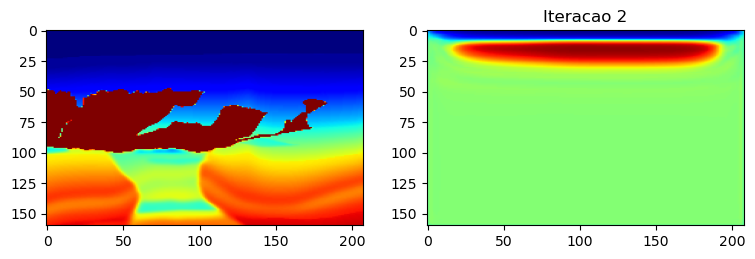

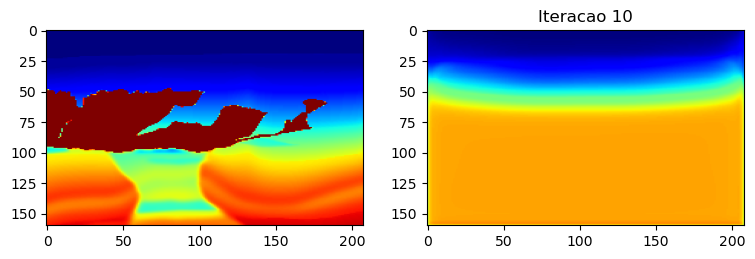

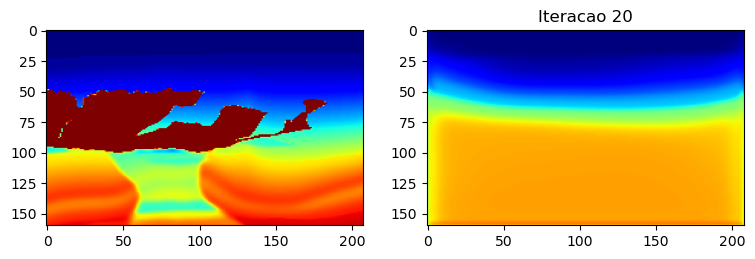

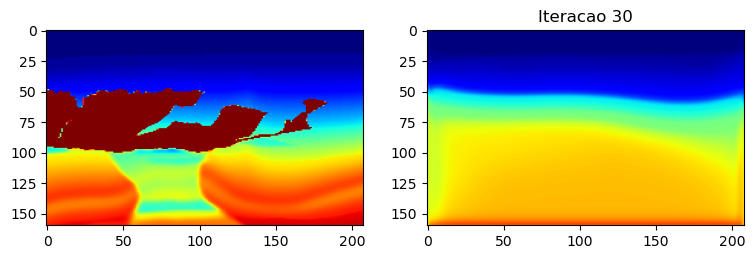

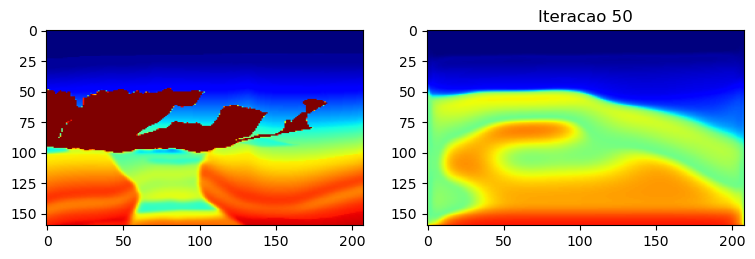

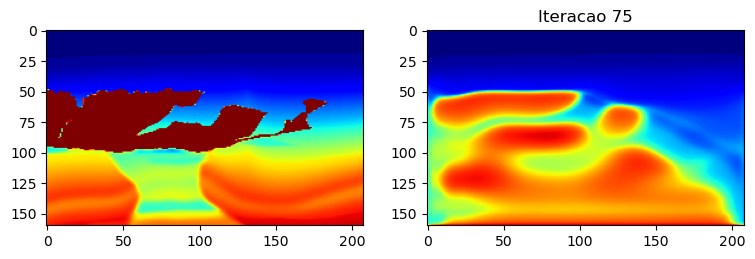

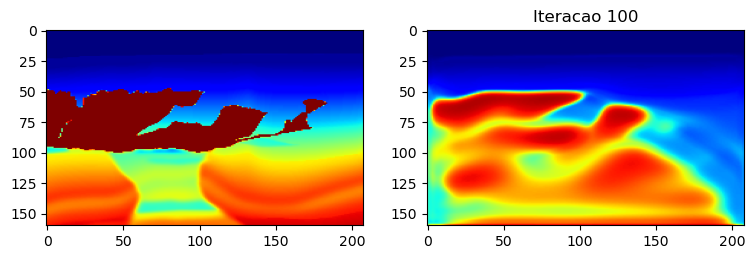

In [17]:
prefixo='BP_t1_'
optimizer = torch.optim.Adam(net.parameters(),lr=1e-3)
criterion = nn.L1Loss()
epochs=101
check_points=[2,10,20,30,50,75,100]
metricas=np.zeros((2,epochs))
L2_model=nn.MSELoss(reduction='mean')
#Begin training
for epoch in range(1, epochs+1):
    net.train()
    epoch_loss = 0
  
    teste=np.arange(num_shots)
    np.random.shuffle(teste)
    ind_vec=np.reshape(teste,(num_batch,batch_size))
    for bc in range(num_batch):
        optimizer.zero_grad()
        yhat = net(x)#modelo de velocidade previsto pela rede, fora da escala
        yhat=torch.squeeze(yhat)[:,:]
        yhat=yhat*(torch.max(model)-torch.min(model)) + torch.min(model)# como a última camada da rede usa uma
        
        #função de ativação sigmoide, é preciso colocar os valores da imagem de saída para os valores reais de velocidade
        yhat=yhat.type(torch.float32)

      
        #modelagem do dado que irá servir de entrada para cálculo da loss do FWI
        out = scalar(yhat,dx,dt,source_amplitudes=source_amplitudes[ind_vec[bc]],
                 source_locations=source_locations[ind_vec[bc]],
                 receiver_locations=receiver_locations[ind_vec[bc]],
                 accuracy=8,
                 pml_freq=peak_freq,pml_width=[50,50,50,50])
        receiver_amplitudes_hat=out[-1]


        #receiver_amplitudes_hat -= receiver_amplitudes_homo[ind_vec[bc]] # elimina a onda direta
        xhat=torch.squeeze(receiver_amplitudes_hat)
        xhat=torch.unsqueeze(xhat,0)
        loss = criterion(xhat,torch.unsqueeze(torch.squeeze(true_seism)[ind_vec[bc]],0)) #loss entre tiros "reais" e simluados


        loss.backward()# backpropagation, passando pela parte física do problema (FWI) e injetando o gradiente da parte física na rede neural
        optimizer.step()
        epoch_loss += loss.item()
            
    epoch_loss=epoch_loss/num_batch
    metricas[0,epoch-1]=epoch_loss
    metricas[1,epoch-1]=L2_model(yhat[:,:],model[:,:].to(device))
    print('Epoca:',epoch, 'Erro dado:', epoch_loss,'Erro modelo:',metricas[1,epoch-1])
    if epoch in check_points:
        fig,ax =plt.subplots(nrows=1,ncols=2,figsize=(9,5))
        ax[0].imshow(model[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].imshow(yhat.cpu().detach().numpy()[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].set_title('Iteracao {}'.format(epoch))
        fig.savefig('./Teste01/'+prefixo+'_{}.png'.format(epoch), format='png')

Agora vamos testar o que acontece quando a rede recebe ruído aleatório como entrada 

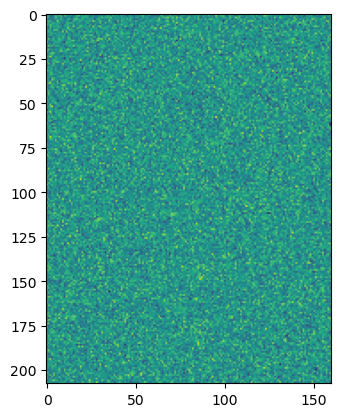

In [18]:
n_filters=36
net=TestEncoderDecoder(num_shots,filters=n_filters).to(device)
xx = torch.randn_like(x) #geração do ruído para entrada, a arquitetura se mantém a mesma
plt.imshow(xx.cpu().numpy()[0,0,:,:])

Epoca: 1 Erro dado: 0.4173927903175354 Erro modelo: 1711018.875
Epoca: 2 Erro dado: 0.30346187204122543 Erro modelo: 1715689.875
Epoca: 3 Erro dado: 0.283737875521183 Erro modelo: 1415287.25
Epoca: 4 Erro dado: 0.2507893368601799 Erro modelo: 816034.5
Epoca: 5 Erro dado: 0.21853920072317123 Erro modelo: 557463.8125
Epoca: 6 Erro dado: 0.18732650205492973 Erro modelo: 570209.375
Epoca: 7 Erro dado: 0.17006459459662437 Erro modelo: 477138.875
Epoca: 8 Erro dado: 0.1585448905825615 Erro modelo: 469205.8125
Epoca: 9 Erro dado: 0.14266740903258324 Erro modelo: 460766.53125
Epoca: 10 Erro dado: 0.1319725662469864 Erro modelo: 419656.9375
Epoca: 11 Erro dado: 0.13976000249385834 Erro modelo: 447406.40625
Epoca: 12 Erro dado: 0.12123611196875572 Erro modelo: 400149.28125
Epoca: 13 Erro dado: 0.11455964483320713 Erro modelo: 420456.8125
Epoca: 14 Erro dado: 0.10997351631522179 Erro modelo: 346430.28125
Epoca: 15 Erro dado: 0.10604287683963776 Erro modelo: 327864.5
Epoca: 16 Erro dado: 0.1106592

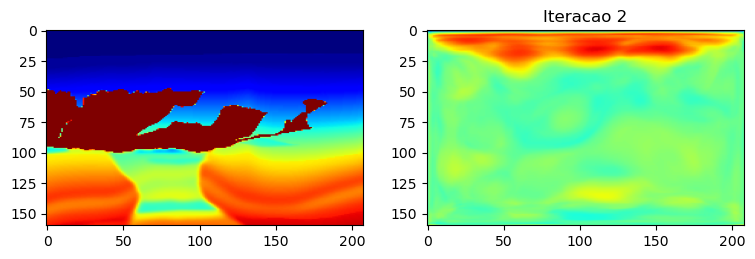

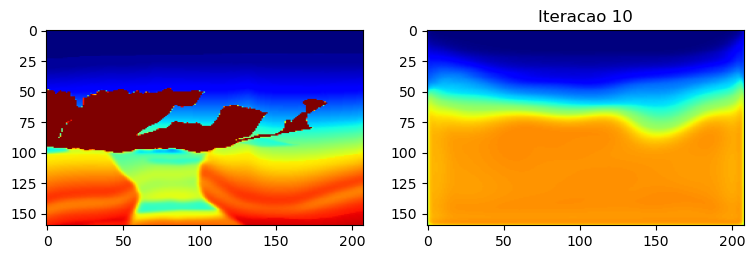

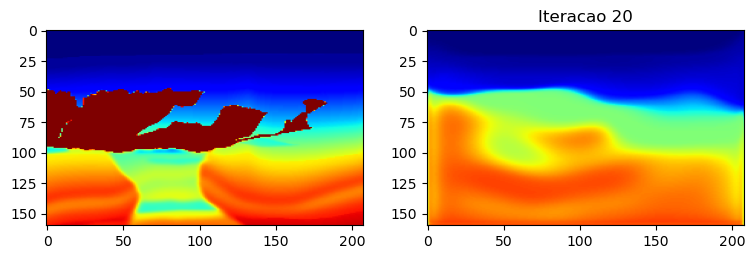

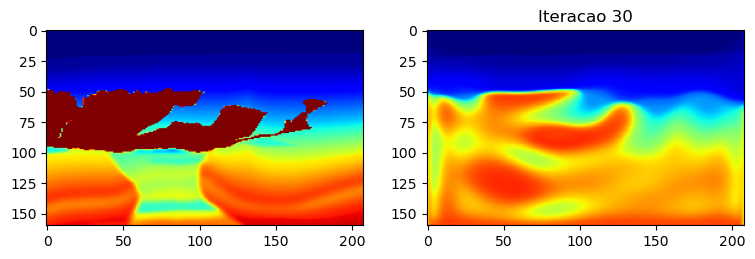

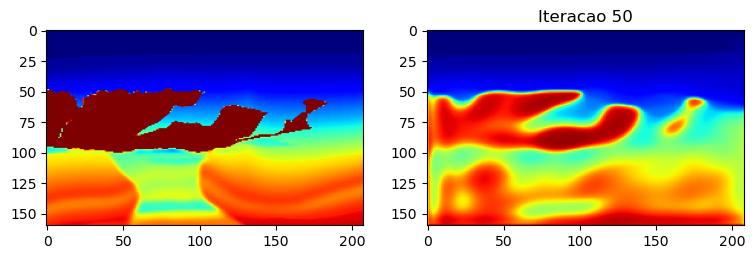

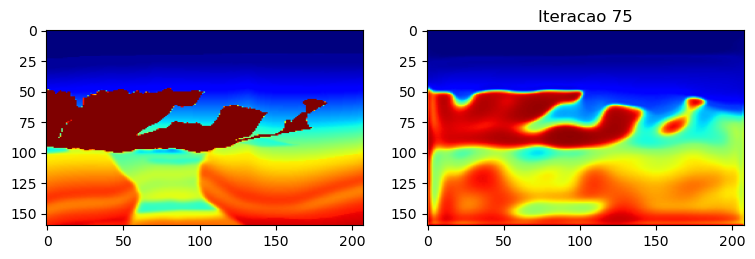

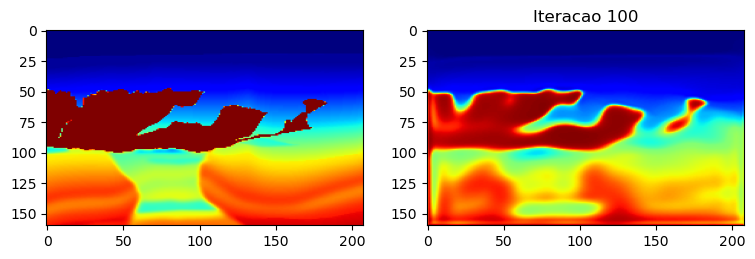

In [19]:
prefixo='BP_t2_'
optimizer = torch.optim.Adam(net.parameters(),lr=1e-3)
criterion = nn.L1Loss()
epochs=101
check_points=[2,10,20,30,50,75,100]
metricas=np.zeros((2,epochs))
L2_model=nn.MSELoss(reduction='mean')
#Begin training
for epoch in range(1, epochs+1):
    net.train()
    epoch_loss = 0
  
    teste=np.arange(num_shots)
    np.random.shuffle(teste)
    ind_vec=np.reshape(teste,(num_batch,batch_size))
    for bc in range(num_batch):
        optimizer.zero_grad()
        yhat = net(xx)#a entrada muda aqui, e passa a ser o ruído aleatório
        yhat=torch.squeeze(yhat)[:,:]
        yhat=yhat*(torch.max(model)-torch.min(model)) + torch.min(model)# como a última camada da rede usa uma
        
        #função de ativação sigmoide, é preciso colocar os valores da imagem de saída para os valores reais de velocidade
        yhat=yhat.type(torch.float32)

      
        #modelagem do dado que irá servir de entrada para cálculo da loss do FWI
        out = scalar(yhat,dx,dt,source_amplitudes=source_amplitudes[ind_vec[bc]],
                 source_locations=source_locations[ind_vec[bc]],
                 receiver_locations=receiver_locations[ind_vec[bc]],
                 accuracy=8,
                 pml_freq=peak_freq,pml_width=[50,50,50,50])
        receiver_amplitudes_hat=out[-1]


        #receiver_amplitudes_hat -= receiver_amplitudes_homo[ind_vec[bc]] # elimina a onda direta
        xhat=torch.squeeze(receiver_amplitudes_hat)
        xhat=torch.unsqueeze(xhat,0)
        loss = criterion(xhat,torch.unsqueeze(torch.squeeze(true_seism)[ind_vec[bc]],0)) #loss entre tiros "reais" e simluados


        loss.backward()# backpropagation, passando pela parte física do problema (FWI) e injetando o gradiente da parte física na rede neural
        optimizer.step()
        epoch_loss += loss.item()
            
    epoch_loss=epoch_loss/num_batch
    metricas[0,epoch-1]=epoch_loss
    metricas[1,epoch-1]=L2_model(yhat[:,:],model[:,:].to(device))
    print('Epoca:',epoch, 'Erro dado:', epoch_loss,'Erro modelo:',metricas[1,epoch-1])
    if epoch in check_points:
        fig,ax =plt.subplots(nrows=1,ncols=2,figsize=(9,5))
        ax[0].imshow(model[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].imshow(yhat.cpu().detach().numpy()[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].set_title('Iteracao {}'.format(epoch))
        fig.savefig('./Teste02/'+prefixo+'_{}.png'.format(epoch), format='png')

Já que a entrada não é usada como informação útil, que tal montar uma arquitetura apenas com o decoder?

In [20]:
class DecoderBlock(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""

    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.decoder_block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.LeakyReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding="same", bias=False),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(inplace=True),
        )

    def forward(self, x):
        return self.decoder_block(x)


class FinalConv(nn.Module):
    """(reduce final feature maps to one channel)"""

    def __init__(self, in_channels, out_channels=1):
        super().__init__()
        self.final_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same", bias=False),

            nn.Sigmoid()
        )

    def forward(self, x):
        return self.final_conv(x)


class TestOnlyDecoder(nn.Module):
    def __init__(self, n_channels,filters):
        super(TestOnlyDecoder, self).__init__()
        self.n_channels = n_channels
        self.filters = filters

        self.decoder_1 = DecoderBlock(1, filters*8)# 1 canal para acomodar a entrada compacta
        self.decoder_2 = DecoderBlock(filters*8, filters*4)
        self.decoder_3 = DecoderBlock(filters*4, filters*2)
        self.decoder_4 = DecoderBlock(filters*2, filters*1)

        self.outc = FinalConv(filters)

    def forward(self, x):

        x6 = self.decoder_1(x)
        x7 = self.decoder_2(x6)
        x8 = self.decoder_3(x7)
        x9 = self.decoder_4(x8)

        logits = self.outc(x9)

        return logits

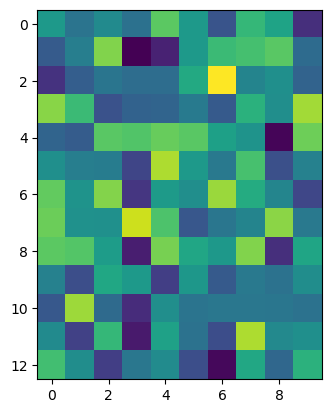

In [21]:
n_filters=36
net=TestOnlyDecoder(1,filters=n_filters).to(device)
xxx = torch.randn(1, 1, 13, 10).to(device) #imagem aleatória do tamanho do vetor latente, mas com apenas 1 canal(feature map), repara que o self.decoder_1 recebe 1 canal
plt.imshow(xxx.cpu().numpy()[0,0,:,:])


Epoca: 1 Erro dado: 0.41304539144039154 Erro modelo: 1504615.25
Epoca: 2 Erro dado: 0.30769263952970505 Erro modelo: 1493080.875
Epoca: 3 Erro dado: 0.2882569953799248 Erro modelo: 1354285.0
Epoca: 4 Erro dado: 0.27231911569833755 Erro modelo: 1301070.625
Epoca: 5 Erro dado: 0.26093776524066925 Erro modelo: 1216484.75
Epoca: 6 Erro dado: 0.2532021030783653 Erro modelo: 1105682.5
Epoca: 7 Erro dado: 0.240098524838686 Erro modelo: 1075464.375
Epoca: 8 Erro dado: 0.23309297487139702 Erro modelo: 988889.25
Epoca: 9 Erro dado: 0.2242235131561756 Erro modelo: 886327.125
Epoca: 10 Erro dado: 0.21806590259075165 Erro modelo: 797584.9375
Epoca: 11 Erro dado: 0.21447408199310303 Erro modelo: 774706.4375
Epoca: 12 Erro dado: 0.20755881816148758 Erro modelo: 718487.75
Epoca: 13 Erro dado: 0.20110824331641197 Erro modelo: 693841.0
Epoca: 14 Erro dado: 0.19002625346183777 Erro modelo: 634625.375
Epoca: 15 Erro dado: 0.17945287004113197 Erro modelo: 608588.4375
Epoca: 16 Erro dado: 0.1731948032975196

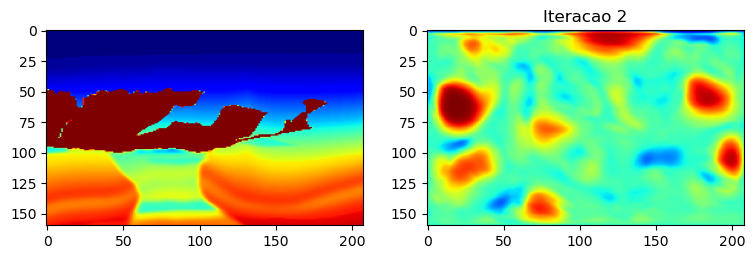

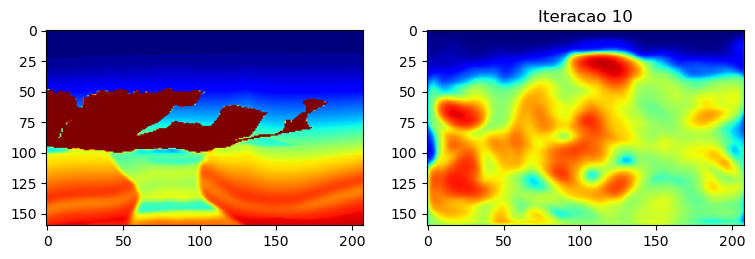

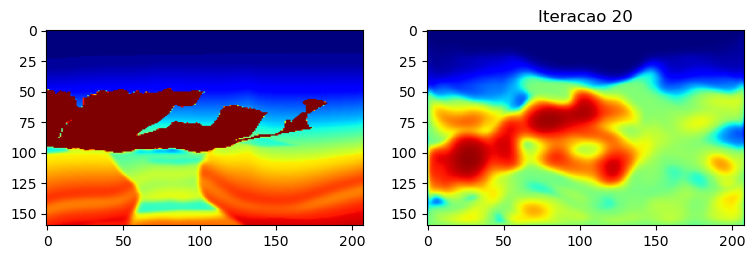

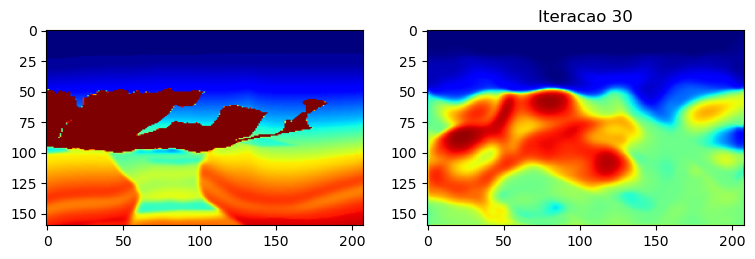

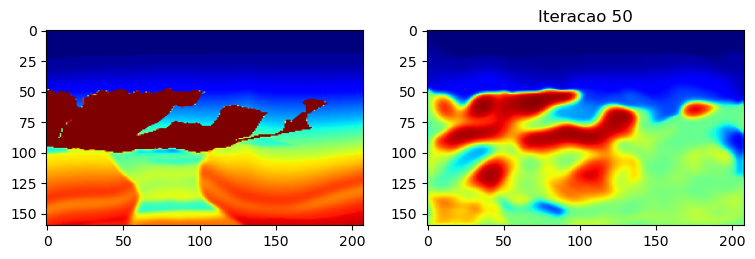

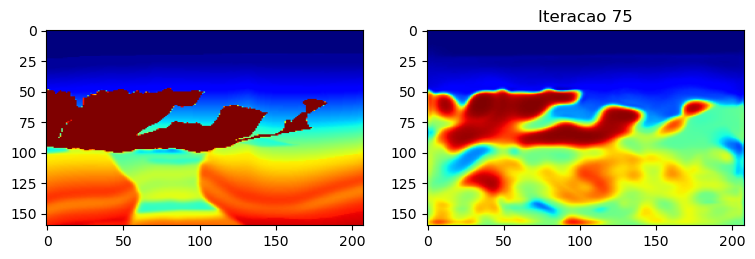

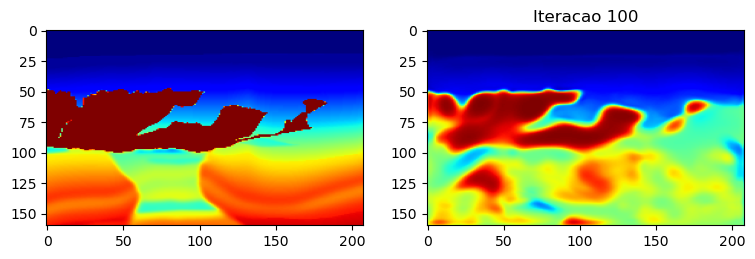

In [22]:
prefixo='BP_t3_'
optimizer = torch.optim.Adam(net.parameters(),lr=1e-3)
criterion = nn.L1Loss()
epochs=101
check_points=[2,10,20,30,50,75,100]
metricas=np.zeros((2,epochs))
L2_model=nn.MSELoss(reduction='mean')
#Begin training
for epoch in range(1, epochs+1):
    net.train()
    epoch_loss = 0
  
    teste=np.arange(num_shots)
    np.random.shuffle(teste)
    ind_vec=np.reshape(teste,(num_batch,batch_size))
    for bc in range(num_batch):
        optimizer.zero_grad()
        yhat = net(xxx)# tensor apenas com ruídos e nas dimensões do espaço latente e apenas um canal
        yhat=torch.squeeze(yhat)[:,:]
        yhat=yhat*(torch.max(model)-torch.min(model)) + torch.min(model)# como a última camada da rede usa uma
        
        #função de ativação sigmoide, é preciso colocar os valores da imagem de saída para os valores reais de velocidade
        yhat=yhat.type(torch.float32)

      
        #modelagem do dado que irá servir de entrada para cálculo da loss do FWI
        out = scalar(yhat,dx,dt,source_amplitudes=source_amplitudes[ind_vec[bc]],
                 source_locations=source_locations[ind_vec[bc]],
                 receiver_locations=receiver_locations[ind_vec[bc]],
                 accuracy=8,
                 pml_freq=peak_freq,pml_width=[50,50,50,50])
        receiver_amplitudes_hat=out[-1]


        #receiver_amplitudes_hat -= receiver_amplitudes_homo[ind_vec[bc]] # elimina a onda direta
        xhat=torch.squeeze(receiver_amplitudes_hat)
        xhat=torch.unsqueeze(xhat,0)
        loss = criterion(xhat,torch.unsqueeze(torch.squeeze(true_seism)[ind_vec[bc]],0)) #loss entre tiros "reais" e simluados


        loss.backward()# backpropagation, passando pela parte física do problema (FWI) e injetando o gradiente da parte física na rede neural
        optimizer.step()
        epoch_loss += loss.item()
            
    epoch_loss=epoch_loss/num_batch
    metricas[0,epoch-1]=epoch_loss
    metricas[1,epoch-1]=L2_model(yhat[:,:],model[:,:].to(device))
    print('Epoca:',epoch, 'Erro dado:', epoch_loss,'Erro modelo:',metricas[1,epoch-1])
    if epoch in check_points:
        fig,ax =plt.subplots(nrows=1,ncols=2,figsize=(9,5))
        ax[0].imshow(model[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].imshow(yhat.cpu().detach().numpy()[:,:].T,aspect=0.8,cmap='jet',vmin=1500,vmax=4500)
        ax[1].set_title('Iteracao {}'.format(epoch))
        fig.savefig('./Teste03/'+prefixo+'_{}.png'.format(epoch), format='png')